# Imports

In [236]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

# Matrix functions

In [237]:
def Biformula(X, Y):
    # algoritm transpusa
    X_t = matrix_transpose(X)

    # algoritm inmultire
    X_tX = matrix_multiply(X_t, X)

    # algoritm inversa
    inv_X_tX = get_matrix_inverse(X_tX)

    matrice = matrix_multiply(inv_X_tX, X_t)

    return matrix_multiply(matrice, Y)


def get_matrix_minor(matrix, i, j):
    return [row[:j] + row[j + 1:] for row in (matrix[:i] + matrix[i + 1:])]


def get_matrix_determinant(matrix):
    # base case for 2x2 matrix
    if len(matrix) == 2:
        return matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]

    determinant = 0
    for c in range(len(matrix)):
        determinant += ((-1) ** c) * matrix[0][c] * get_matrix_determinant(get_matrix_minor(matrix, 0, c))
    return determinant


def get_matrix_inverse(matrix):
    determinant = get_matrix_determinant(matrix)
    if determinant == 0:
        raise ValueError("Matrix is not invertible")

    # special case for 2x2 matrix:
    if len(matrix) == 2:
        return [[matrix[1][1] / determinant, -1 * matrix[0][1] / determinant],
                [-1 * matrix[1][0] / determinant, matrix[0][0] / determinant]]

    # find matrix of cofactors
    cofactors = []
    for r in range(len(matrix)):
        cofactorRow = []
        for c in range(len(matrix)):
            minor = get_matrix_minor(matrix, r, c)
            cofactorRow.append(((-1) ** (r + c)) * get_matrix_determinant(minor))
        cofactors.append(cofactorRow)
    cofactors = list(map(list, zip(*cofactors)))  # transpose the matrix
    for r in range(len(cofactors)):
        for c in range(len(cofactors)):
            cofactors[r][c] = cofactors[r][c] / determinant
    return cofactors


def matrix_multiply(A, B):
    # Get the number of rows and columns for the matrices
    rows_A, cols_A = len(A), len(A[0])
    rows_B, cols_B = len(B), len(B[0])

    # Check if the matrices can be multiplied
    if cols_A != rows_B:
        raise ValueError("Cannot multiply matrices: Number of columns in A must equal number of rows in B")

    # Initialize the result matrix with zeros
    result = [[0 for _ in range(cols_B)] for _ in range(rows_A)]

    # Perform the multiplication
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]

    return result


def matrix_transpose(matrix):
    # Get the number of rows and columns for the matrix
    rows, cols = len(matrix), len(matrix[0])

    # Initialize the transpose matrix with zeros
    transpose = [[0 for _ in range(rows)] for _ in range(cols)]

    # Perform the transpose
    for i in range(rows):
        for j in range(cols):
            transpose[j][i] = matrix[i][j]

    return transpose


# Functii pentru probleme : 

## - Citirea datelor - univariate

In [238]:
#Sursa -  AI-UBB
def UniloadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1

    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))
              if data[i][selectedVariable] != '']

    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))
               if data[i][selectedVariable] != '']

    return inputs, outputs

## - Citirea datelor - bivariate

In [239]:
def BiloadData(fileName, inputVariabNameFirst, inputVariabNameSecond, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1

    selectedVariableFirst = dataNames.index(inputVariabNameFirst)
    selectedVariableSecond = dataNames.index(inputVariabNameSecond)

    inputsFirst = [float(data[i][selectedVariableFirst]) for i in range(len(data))
                   if data[i][selectedVariableFirst] != ''
                   and data[i][selectedVariableSecond] != '']

    inputsSecond = [float(data[i][selectedVariableSecond]) for i in range(len(data))
                    if data[i][selectedVariableFirst] != ''
                    and data[i][selectedVariableSecond] != '']

    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))
               if data[i][selectedVariableFirst] != ''
               and data[i][selectedVariableSecond] != '']

    return inputsFirst, inputsSecond, outputs

## - Historgrame

In [240]:
#Sursa -  AI-UBB
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

## - Verificarea lineritati prin Grafic - Univariata

In [241]:
#Sursa -  AI-UBB
def UniLiniarPlot(inputs, outputs, labelInput, labelOutput):
    plt.plot(inputs, outputs, 'ro', label='train data')
    plt.xlabel(labelInput)
    plt.ylabel(labelOutput)
    plt.legend()
    plt.show()

## - Verificarea lineritati prin Grafic - Bivariata

In [242]:
def BiLiniarPlot(inputsFirst, inputsSecond, outputs, labelInputFirst, labelInputSecond, labelOutput):
    ax = plt.figure().add_subplot(projection='3d')

    ax.scatter(inputsFirst, inputsSecond, outputs, c='r', marker='o', label='train data')
    ax.set_xlabel(labelInputFirst)
    ax.set_ylabel(labelInputSecond)
    ax.set_zlabel(labelOutput)

    plt.legend()
    plt.show()

## - Selectarea Random a datelor de train si validare - Univariata

In [243]:
#Sursa -  AI-UBB
def UniSelectTVdata(inputs, outputs, labelInput, labelOutput, seed=5):
    np.random.seed(seed)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    validationSample = [i for i in indexes if not i in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]

    validationInputs = [inputs[i] for i in validationSample]
    validationOutputs = [outputs[i] for i in validationSample]

    plt.plot(trainInputs, trainOutputs, 'ro', label='training data')  #train data are plotted by red and circle sign
    plt.plot(validationInputs, validationOutputs, 'g^',
             label='validation data')  #test data are plotted by green and a triangle sign
    plt.title('train and validation data')
    plt.xlabel(labelInput)
    plt.ylabel(labelOutput)
    plt.legend()
    plt.show()

    return trainInputs, trainOutputs, validationInputs, validationOutputs

## - Selectarea Random a datelor de train si validare - Bivariata

In [244]:
def BiSelectTVdata(inputsFirst, inputsSecond, outputs, labelInputFirst, labelInputSecond, labelOutput, seed=5):
    np.random.seed(seed)
    indexes = [i for i in range(len(inputsFirst))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputsFirst)), replace=False)
    validationSample = [i for i in indexes if not i in trainSample]

    trainInputsFirst = [inputsFirst[i] for i in trainSample]
    trainInputsSecond = [inputsSecond[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]

    validationInputsFirst = [inputsFirst[i] for i in validationSample]
    validationInputsSecond = [inputsSecond[i] for i in validationSample]
    validationOutputs = [outputs[i] for i in validationSample]

    ax = plt.figure().add_subplot(projection='3d')
    ax.scatter(inputsFirst, inputsSecond, outputs, c='r', marker='o')

    ax.plot(trainInputsFirst, trainInputsSecond, trainOutputs, 'ro', label='training data')
    ax.plot(validationInputsFirst, validationInputsSecond, validationOutputs, 'g^', label='validation data')

    plt.title('train and validation data')
    ax.set_xlabel(labelInputFirst)
    ax.set_ylabel(labelInputSecond)
    ax.set_zlabel(labelOutput)

    plt.legend()
    plt.show()

    return trainInputsFirst, trainInputsSecond, trainOutputs, validationInputsFirst, validationInputsSecond, validationOutputs

## - Model Learning (Metoda Patratelor) - Univariata :

### 1. Tool

In [245]:
#Sursa -  AI-UBB
def UniModelLearningTool(trainInputs, trainOutputs):
    xx = [[el] for el in trainInputs]
    regressor = linear_model.LinearRegression()
    regressor.fit(xx, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_[0]
    return w0, w1, regressor

### 2. Code
used the formulas : 
$$
w_1 = \frac{n \sum_{i=1}^{n} (x^i * y^i) - \sum_{i=1}^{n} x^i * \sum_{i=1}^{n} y^i}
{n \sum_{i=1}^{n} (x^i)^2 - (\sum_{i=1}^{n} x^i)^2}
$$

$$
w_0 = \frac{\sum_{i=1}^{n} y^i - w_1 \sum_{i=1}^{n} x^i}{n}
$$


## Definitions  

- $n$ = Number of training inputs  
- $x_i$ = Input feature at index $i$  
- $y_i$ = Output (target) corresponding to $x_i$  
- $i = 1, 2, \dots, n$ (Index ranging from 1 to $n$)  


In [246]:
def UniModelLearningCode(trainInputs, trainOutputs):
    n = len(trainOutputs)
    sumXY = sum(list([x * y for x, y in zip(trainInputs, trainOutputs)]))
    sumX = sum(trainInputs)
    sumY = sum(trainOutputs)
    sumXsqr = sum([x ** 2 for x in trainInputs])

    w1 = (n * sumXY - sumX * sumY) / (n * sumXsqr - sumX ** 2)
    w0 = (sumY - w1 * sumX) / n

    return w0, w1

## - Model Learning (Metoda Patratelor) - Bivariata :

### 1.Tool

In [247]:
def BiModelLearningTool(trainInputsFirst, trainInputsSecond, trainOutputs):
    xx = list([[f, s] for f, s in zip(trainInputsFirst, trainInputsSecond)])
    regressor = linear_model.LinearRegression()
    regressor.fit(xx, trainOutputs)
    w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

    return w0, w1, w2, regressor

### 2.Code
Pentru cazul unei regresii multi-variate (\(m\) atribute): 
$ f(x, w) = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \dots + w_m \cdot x_m \) $
și un set de date cu \(n\) exemple:

$$
w = (X^T X)^{-1} X^T Y
$$

unde $\( X = (x_{ij}) \), \( Y = (y^i) \), \( i = 1,2,\dots,n \), \( j = 1,2,\dots,m \)$.

In [248]:
def BiModelLearningCode(trainInputsFirst, trainInputsSecond, trainOutputs):
    X = list([[1, i, j] for i, j in zip(trainInputsFirst, trainInputsSecond)])
    Y = list([x] for x in trainOutputs)
    w = Biformula(X,Y)
    return w[0][0], w[1][0], w[2][0]

## - Plot rezultate ( tool si cod ) - Univariata:
$$ f(x) = w_0 + w_1*x $$

In [249]:
#Sursa -  AI-UBB 50%
def UniplotLearning(trainInputs, trainOutputs, tw0, tw1, cw0, cw1, labelInput, labelOuput):
    noOfPoints = 1000
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints

    for i in range(1, noOfPoints):
        xref.append(val)
        val += step
    tyref = [tw0 + tw1 * el for el in xref]
    cyref = [cw0 + cw1 * el for el in xref]

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    plt.title('plot regresions')
    ax[0].plot(trainInputs, trainOutputs, 'ro', label='training data')  #train data are plotted by red and circle sign
    ax[0].plot(xref, tyref, 'b-', label='learnt model by tool')  #model is plotted by a blue line

    ax[1].plot(trainInputs, trainOutputs, 'ro')
    ax[1].plot(xref, cyref, 'g-', label='learnt model by code')

    ax[0].set_title("Plot Tool")
    ax[1].set_title("Plot Code")

    ax[0].set_xlabel(labelInput)
    ax[0].set_ylabel(labelOuput)

    ax[1].set_xlabel(labelInput)
    ax[1].set_ylabel(labelOuput)

    fig.legend()

    plt.show()


## - Plot rezultate ( tool si cod ) - Bivariata:
$$ f(x_1,x_2) = w_0 + w_1*x_1 + w_2*x_2 $$

In [250]:
def BiplotLearning(trainInputsFirst,trainInputsSecond, trainOutputs, tw0, tw1, tw2, cw0, cw1, cw2, labelInputFirst, labelInputSecond, labelOuput):
    
    noOfPoints = 1000
    xref = np.linspace(min(trainInputsFirst), max(trainInputsFirst), noOfPoints)
    yref = np.linspace(min(trainInputsSecond), max(trainInputsSecond), noOfPoints)

    tzref = tw0 + tw1 * xref + tw2 * yref
    czref = cw0 + cw1 * xref + cw2 * yref
    
    fig ,ax = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': '3d'})
    
    ax[0].scatter(trainInputsFirst, trainInputsSecond, trainOutputs, c='r', marker='o', label='train data')
    ax[1].scatter(trainInputsFirst, trainInputsSecond, trainOutputs, c='r', marker='o')
    
    ax[0].plot(xref, yref, tzref ,color='b',label='plot tool')  #model is plotted by a blue plane
    ax[1].plot(xref, yref, czref ,color='g',label='plot code')  #model is plotted by a green plane
    
    ax[0].set_xlabel(labelInputFirst)
    ax[1].set_xlabel(labelInputFirst)
    ax[0].set_ylabel(labelInputSecond)
    ax[1].set_ylabel(labelInputSecond)
    ax[0].set_zlabel(labelOuput)
    ax[1].set_zlabel(labelOuput)
    
    
    plt.legend()
    plt.show()

## PredicitonView - Univariata

In [251]:
#Sursa -  AI-UBB - 50%
def UniPredictView(validationInputs, validationOutputs, regressor, cw0, cw1, labelInput, labelOutput):
    fig2, ax = plt.subplots(1, 2, figsize=(15, 5))

    TcomputedValidationOutputs = regressor.predict([[x] for x in validationInputs])
    CcomputedValidationOutputs = [cw0 + cw1 * x for x in validationInputs]

    ax[0].plot(validationInputs, validationOutputs, 'y^',
               label='real test data')  #real test data are plotted by yellow triangles
    ax[1].plot(validationInputs, validationOutputs, 'y^')

    ax[0].plot(validationInputs, TcomputedValidationOutputs, 'bo', label='computed test data tool')
    ax[1].plot(validationInputs, CcomputedValidationOutputs, 'go', label='computed test data code')

    plt.title('computed validation and real validation data')

    ax[0].set_title("Plot Tool")
    ax[1].set_title("Plot Code")

    ax[0].set_xlabel(labelInput)
    ax[0].set_ylabel(labelOutput)

    ax[1].set_xlabel(labelInput)
    ax[1].set_ylabel(labelOutput)

    fig2.legend()

    plt.show()

    return TcomputedValidationOutputs, CcomputedValidationOutputs

## PredicitonView - Bivariata

In [252]:
def BiPredictView(validationInputsFirst, validationInputsSecond,validationOutputs, regressor, cw0, cw1, cw2, labelInputFirst, labelInputSecond, labelOutput):
    fig2, ax = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': '3d'})

    TcomputedValidationOutputs = regressor.predict([[x, y] for x, y in zip(validationInputsFirst, validationInputsSecond)])
    CcomputedValidationOutputs = [cw0 + cw1 * x + cw2 * y for x, y in zip(validationInputsFirst, validationInputsSecond)]

    ax[0].scatter(validationInputsFirst,validationInputsSecond, validationOutputs, c='y',marker='^',label='real test data')  #real test data are plotted by yellow triangles
    ax[1].scatter(validationInputsFirst,validationInputsSecond, validationOutputs, c='y',marker='^') 

    ax[0].scatter(validationInputsFirst, validationInputsSecond, TcomputedValidationOutputs, c='b',marker='o' ,label='computed test data tool')
    ax[1].scatter(validationInputsFirst, validationInputsSecond, CcomputedValidationOutputs, c='g',marker='o', label='computed test data code')

    ax[0].set_xlabel(labelInputFirst)
    ax[1].set_xlabel(labelInputFirst)
    ax[0].set_ylabel(labelInputSecond)
    ax[1].set_ylabel(labelInputSecond)
    ax[0].set_zlabel(labelOutput)
    ax[1].set_zlabel(labelOutput)

    plt.title('computed validation and real validation data')

    ax[0].set_title("Plot Tool")
    ax[1].set_title("Plot Code")

    fig2.legend()

    plt.show()

    return TcomputedValidationOutputs, CcomputedValidationOutputs

## - Functii de eroare:

  $$
  Error = \frac{1}{n} \times \sum_{i=1}^{n}  (y^i - y^i_{computed}) ^ 2 
  $$


In [253]:
#Sursa -  AI-UBB
#VO - Validation Outputs
def ManualError(computedVO, VO):
    er = 0.0
    for t1, t2 in zip(computedVO, VO):
        er += (t1 - t2) ** 2
    er = er / len(VO)
    return er


def ToolError(computedVO, VO):
    return mean_squared_error(VO, computedVO)

## - Problem solving function Univariata

In [254]:
def SolveUnivariata(filename, inputVariabName, outputVariableName, labelInput, labelOutput, directory='dataLab5'):
    #read Data
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, directory, filename)

    inputs, outputs = UniloadData(filePath, inputVariabName, outputVariableName)

    #histograms and plot
    plotDataHistogram(inputs, labelInput)
    plotDataHistogram(outputs, labelOutput)

    UniLiniarPlot(inputs, outputs, labelInput, labelOutput)

    #train inputs , train outputs , validation inputs , validation outputs
    TI, TO, VI, VO = UniSelectTVdata(inputs, outputs, labelInput, labelOutput)

    #w1,w2 from tool algorithm
    tw0, tw1, regresor = UniModelLearningTool(TI, TO)
    print(f"Functia calculata de tool : f(x) = {tw0} + {tw1} * x = y \n w0 = {tw0} \n w1 = {tw1}")

    #w1,w2 from code algorithm
    cw0, cw1 = UniModelLearningCode(TI, TO)
    print(f"Functia calculata de code : f(x) = {cw0} + {cw1} * x = y \n w0 = {cw0} \n w1 = {cw1}")

    UniplotLearning(TI, TO, tw0, tw1, cw0, cw1, labelInput, labelOutput)
    #tool/code compilated values 
    tc, cc = UniPredictView(VI, VO, regresor, cw0, cw1, labelInput, labelOutput)

    print("Erori outputs:")
    print(f"Eroare tool manuala : {ManualError(tc, VO)}")
    print(f"Eroare tool cu tool : {ManualError(cc, VO)}")
    print(f"Eroare code manuala : {ToolError(tc, VO)}")
    print(f"Eroare code cu tool : {ToolError(tc, VO)}")

## - Problem solving function Bivariata

In [255]:
def SolveBivariata(filename, inputVariableNameFirst, inputVariableNameSecond, outputVariableName,
                   labelInputFirst, labelInputSecond, labelOuput, directory='datalab5'):
    #read Data
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, directory, filename)

    inputsFirst, inputsSecond, outputs = BiloadData(filePath, inputVariableNameFirst, inputVariableNameSecond,
                                                    outputVariableName)

    plotDataHistogram(inputsFirst, labelInputFirst)
    plotDataHistogram(inputsSecond, labelInputSecond)
    plotDataHistogram(outputs, labelOuput)

    BiLiniarPlot(inputsFirst, inputsSecond, outputs, labelInputFirst, labelInputSecond, labelOuput)

    TIF, TIS, TO, VIF, VIS, VO = BiSelectTVdata(inputsFirst, inputsSecond, outputs, labelInputFirst, labelInputSecond,
                                                labelOuput)

    tw0, tw1, tw2, regressor = BiModelLearningTool(TIF, TIS, TO)
    
    print(tw0)
    print(tw1)
    print(tw2)
    
    cw0,cw1,cw2 = BiModelLearningCode(TIF,TIS,TO)
    
    print(cw0)
    print(cw1)
    print(cw2)
    
    BiplotLearning(TIF, TIS, TO, tw0, tw1, tw2, cw0, cw1, cw2, labelInputFirst, labelInputSecond, labelOuput)
    
    tc, cc = BiPredictView(VIF, VIS, VO , regressor, cw0, cw1, cw2, labelInputFirst, labelInputSecond, labelOuput)
    
    print("Erori outputs:")
    print(f"Eroare tool manuala : {ManualError(tc, VO)}")
    print(f"Eroare tool cu tool : {ManualError(cc, VO)}")
    print(f"Eroare code manuala : {ToolError(tc, VO)}")
    print(f"Eroare code cu tool : {ToolError(tc, VO)}")


# Probleme :

## V1:

### 1. doar de Produsul intern brut 

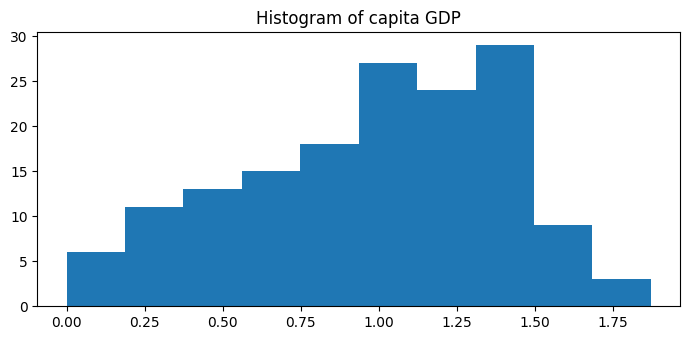

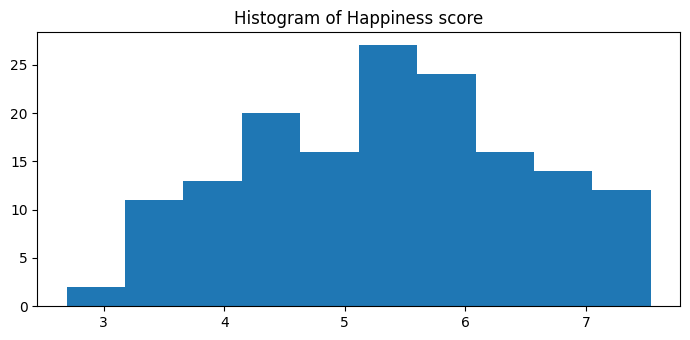

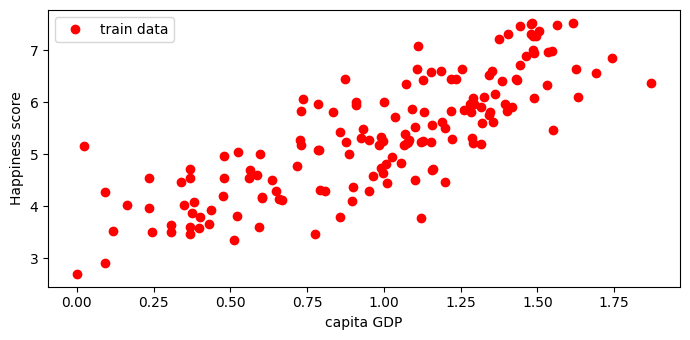

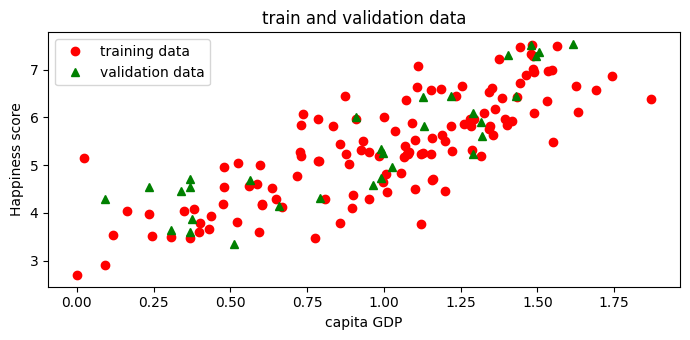

Functia calculata de tool : f(x) = 3.2007686226678995 + 2.1503460961741077 * x = y 
 w0 = 3.2007686226678995 
 w1 = 2.1503460961741077
Functia calculata de code : f(x) = 3.2007686226678964 + 2.150346096174109 * x = y 
 w0 = 3.2007686226678964 
 w1 = 2.150346096174109


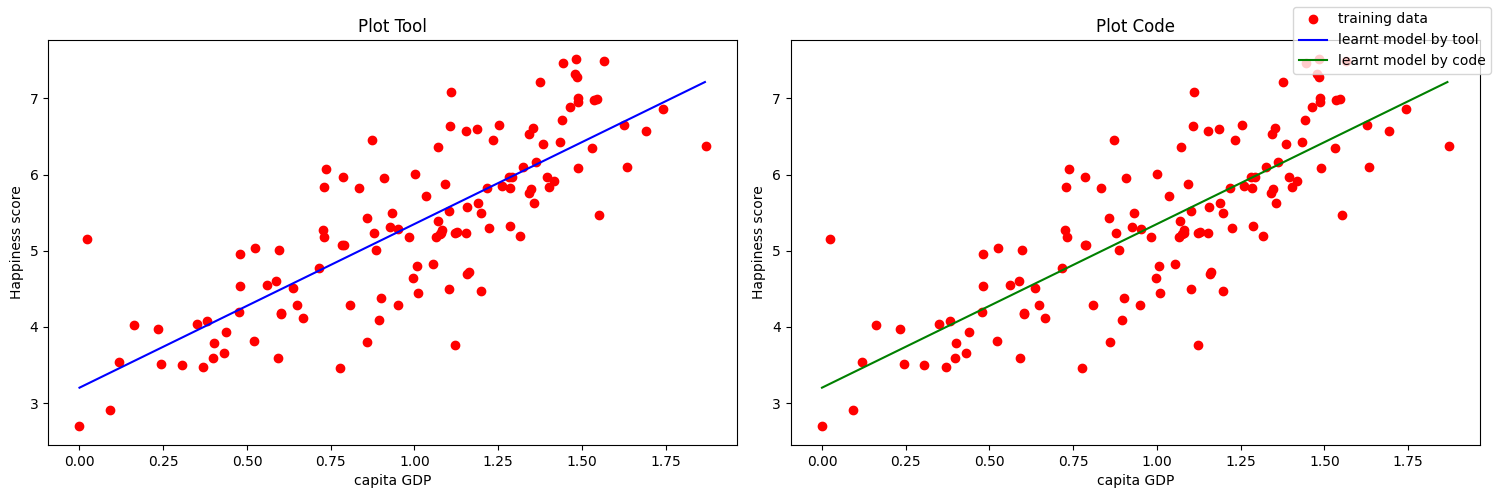

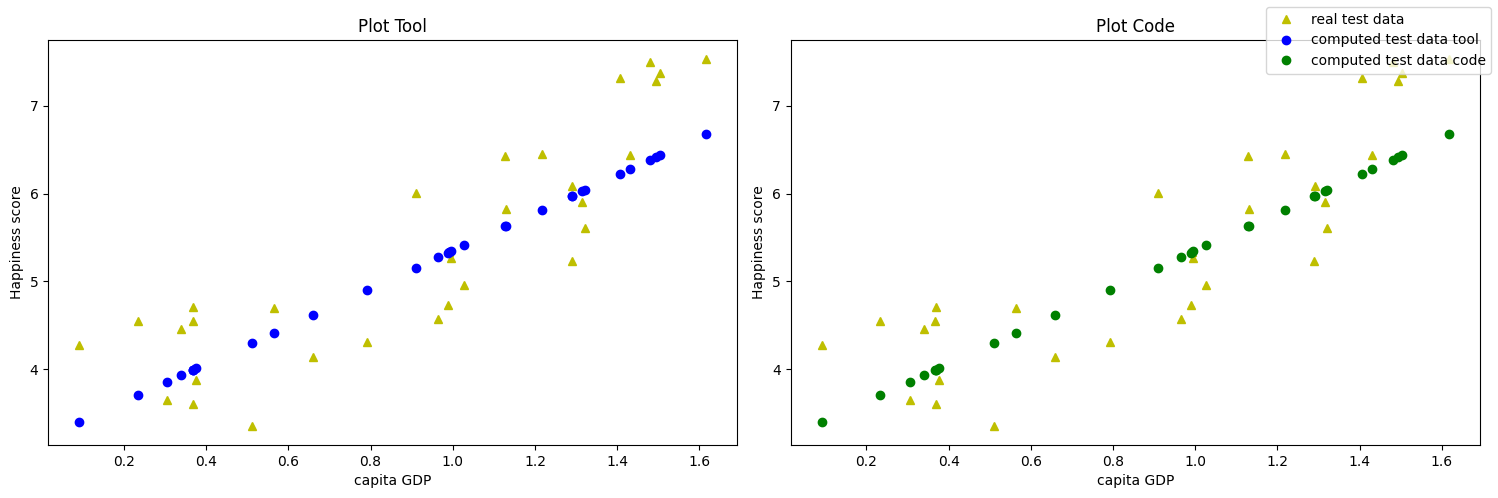

Erori outputs:
Eroare tool manuala : 0.4142120438505252
Eroare tool cu tool : 0.4142120438505258
Eroare code manuala : 0.41421204385052524
Eroare code cu tool : 0.41421204385052524


In [256]:
SolveUnivariata(filename='v1_world-happiness-report-2017.csv',
                inputVariabName='Economy..GDP.per.Capita.',
                outputVariableName='Happiness.Score',
                labelInput='capita GDP',
                labelOutput='Happiness score')

### 2. doar de caracteristica "Family" 

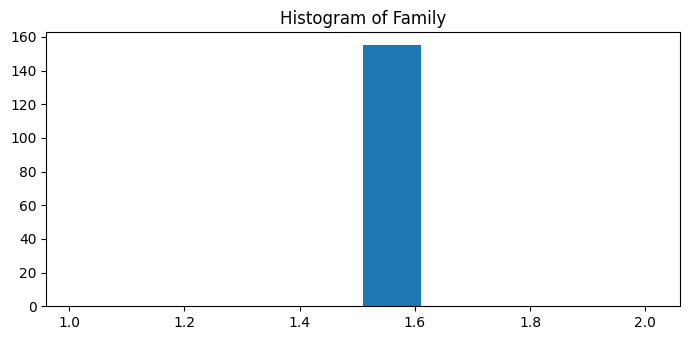

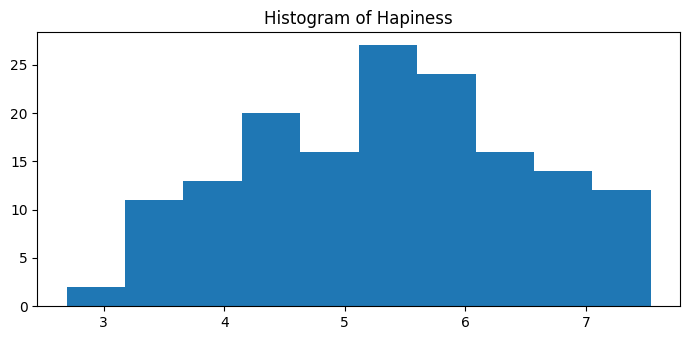

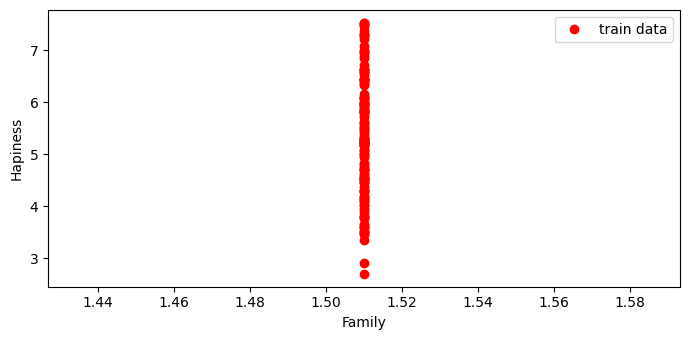

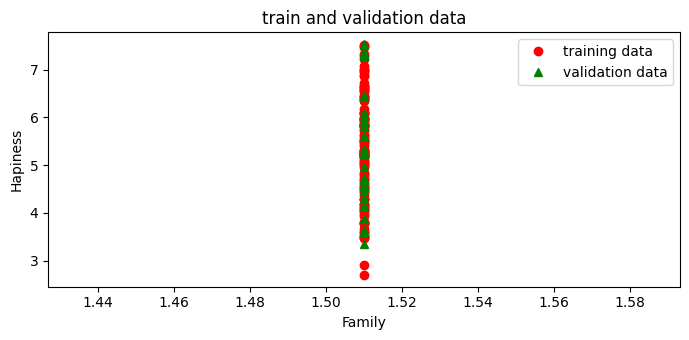

Functia calculata de tool : f(x) = 0.4719180650554877 + 3.2328954364819484 * x = y 
 w0 = 0.4719180650554877 
 w1 = 3.2328954364819484
Functia calculata de code : f(x) = 5.3537258005725805 + 0.0 * x = y 
 w0 = 5.3537258005725805 
 w1 = 0.0


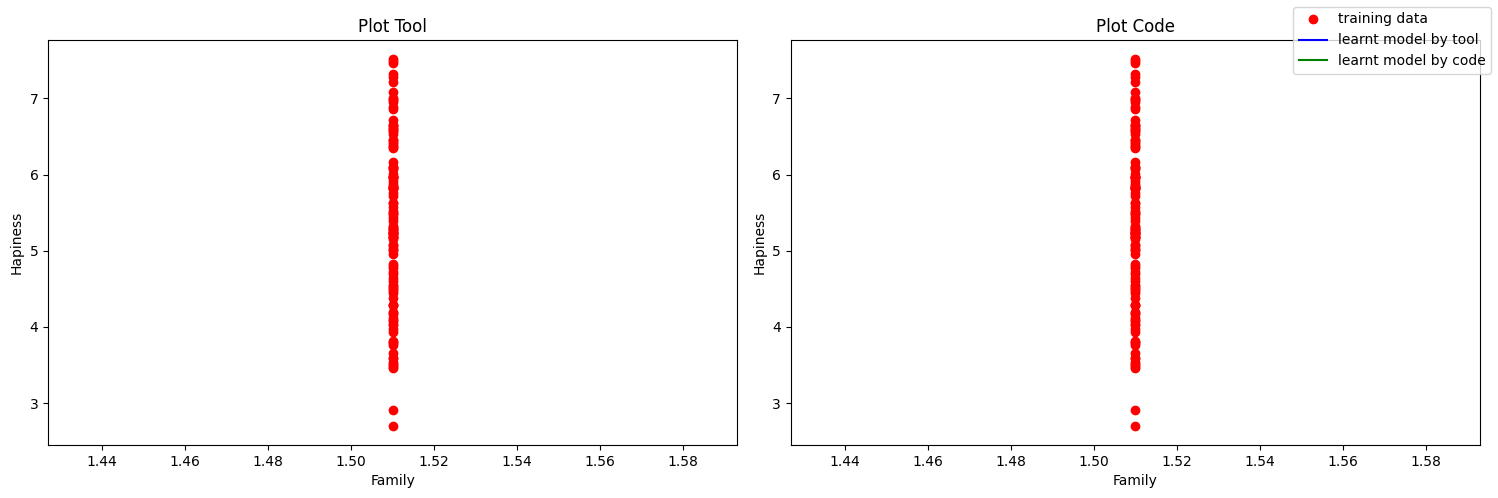

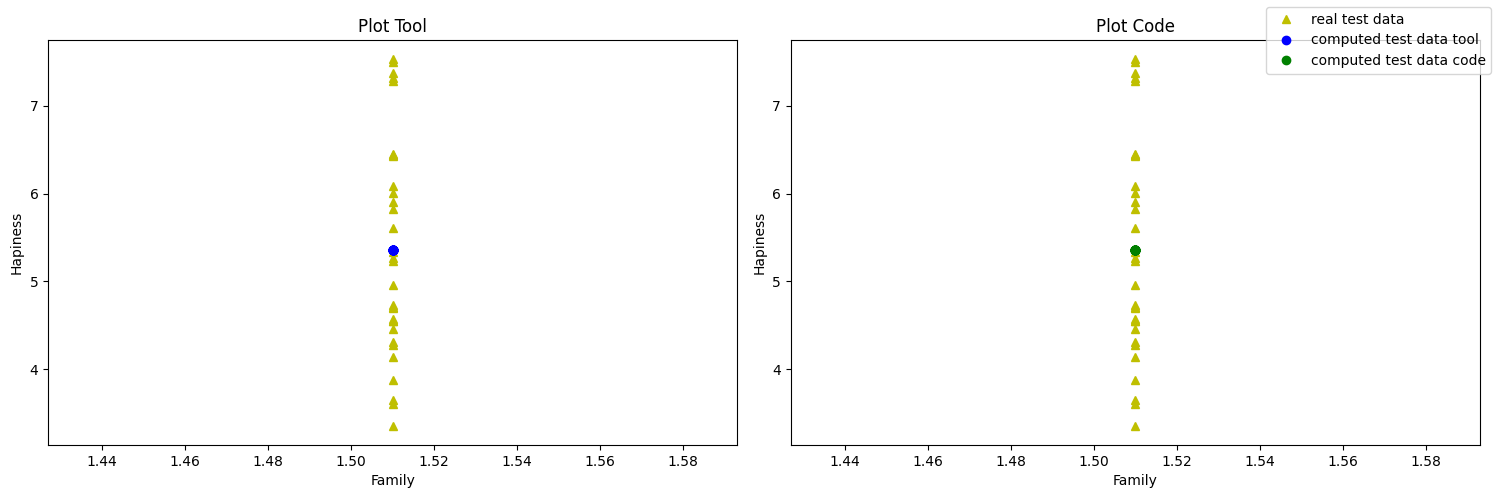

Erori outputs:
Eroare tool manuala : 1.488969965516146
Eroare tool cu tool : 1.488969965516146
Eroare code manuala : 1.488969965516146
Eroare code cu tool : 1.488969965516146


In [257]:
SolveUnivariata(filename='v1_world-happiness-report-2017.csv',
                inputVariabName='Family',
                outputVariableName='Happiness.Score',
                labelInput='Family',
                labelOutput='Hapiness')

### 3.de Produsul intern brut si de gradul de libertate.

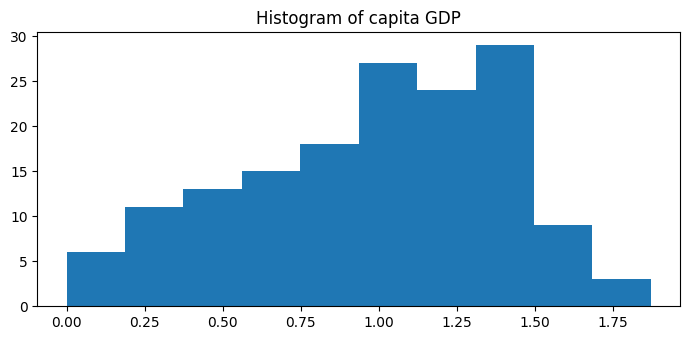

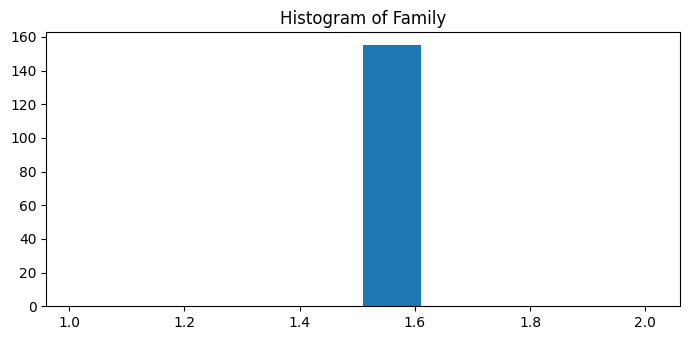

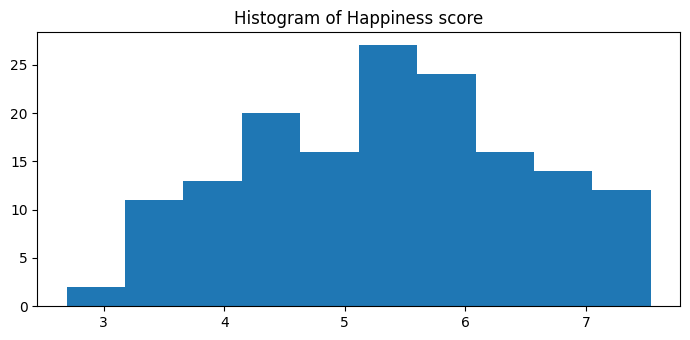

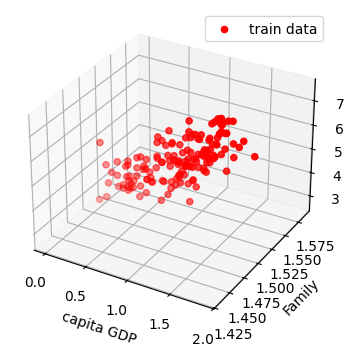

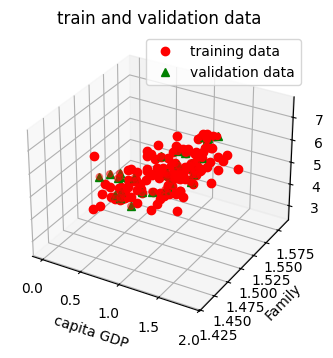

3.2007686226679
2.1503460961741068
0.0
-12.19379684166797
18.70983647368372
16.275042922837898


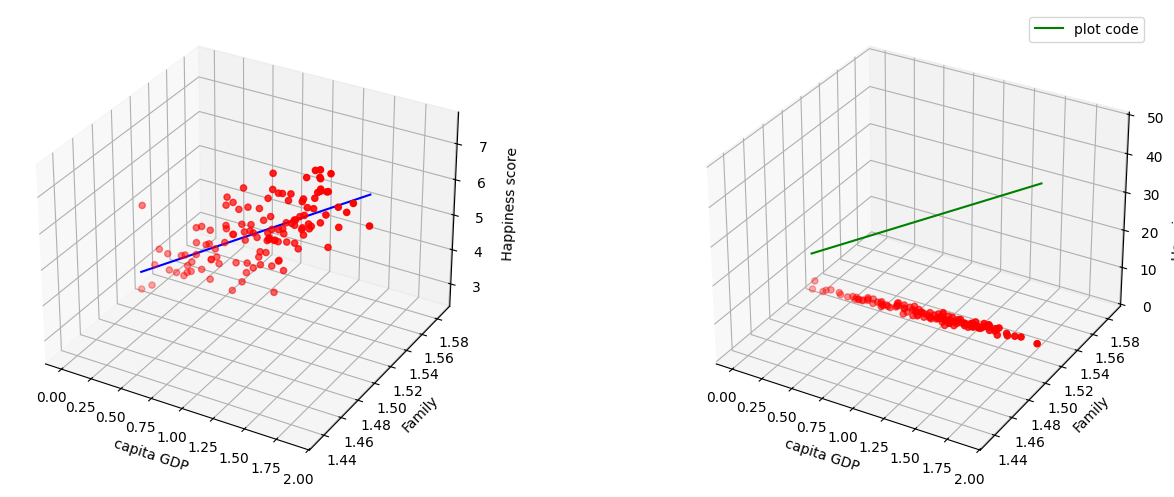

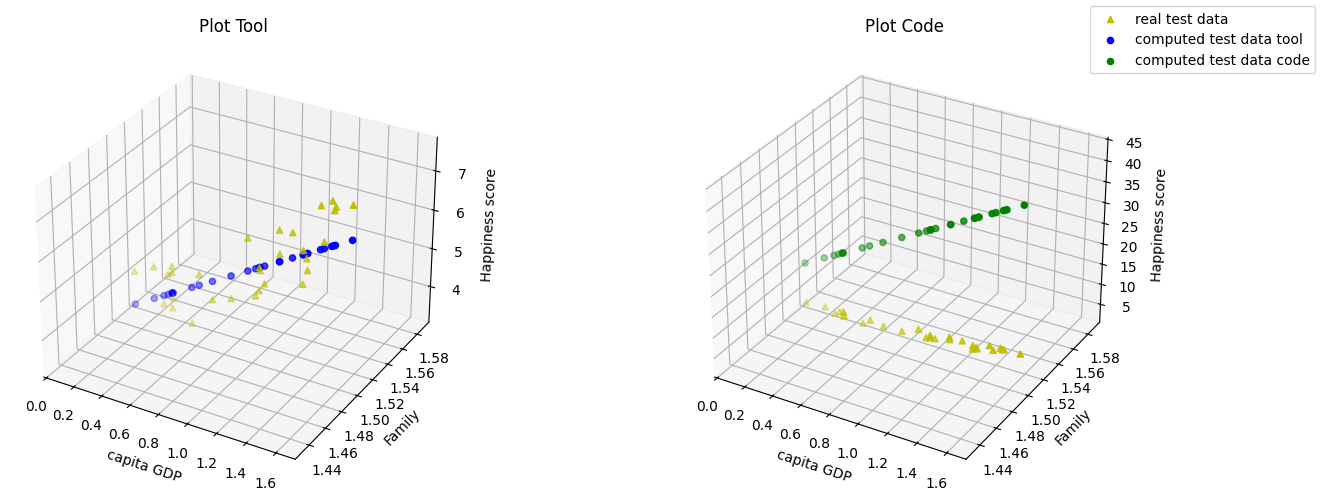

Erori outputs:
Eroare tool manuala : 0.41421204385052524
Eroare tool cu tool : 640.4700245147154
Eroare code manuala : 0.41421204385052535
Eroare code cu tool : 0.41421204385052535


In [258]:
SolveBivariata(filename='v1_world-happiness-report-2017.csv',
               inputVariableNameFirst='Economy..GDP.per.Capita.',
               inputVariableNameSecond='Family',
               outputVariableName='Happiness.Score',
               labelInputFirst='capita GDP',
               labelInputSecond='Family',
               labelOuput='Happiness score')

## V2:

### 1. doar de Produsul intern brut 

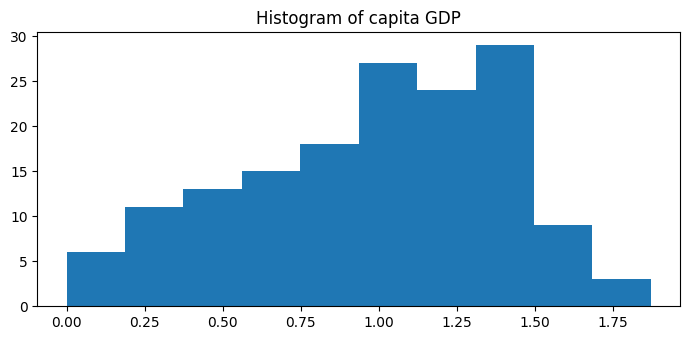

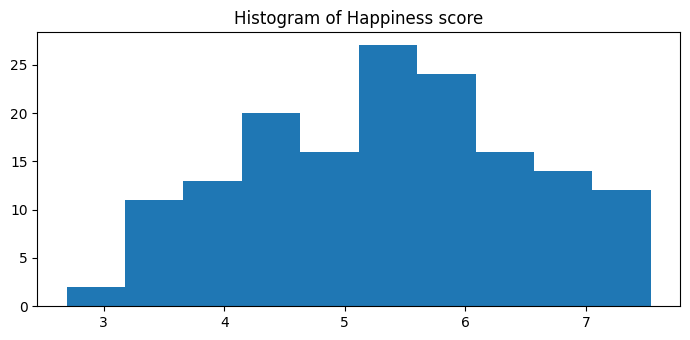

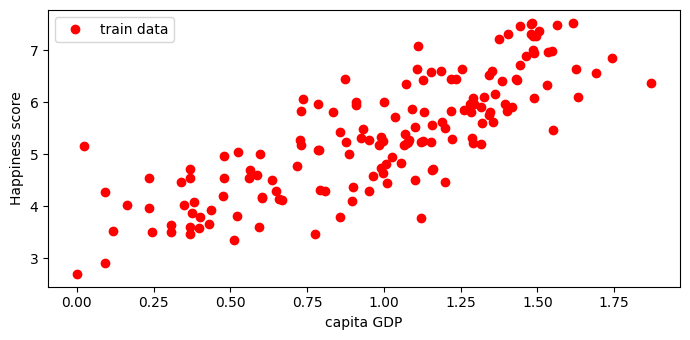

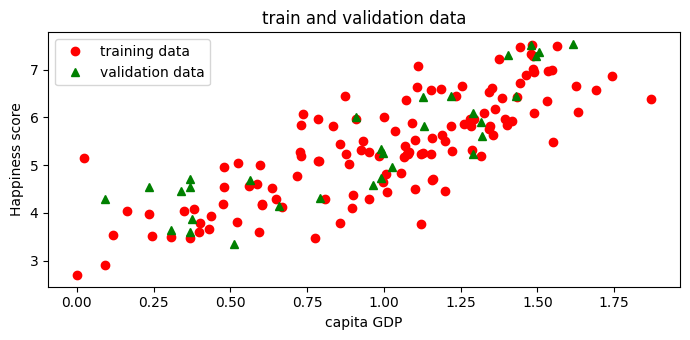

Functia calculata de tool : f(x) = 3.2007686226678995 + 2.1503460961741077 * x = y 
 w0 = 3.2007686226678995 
 w1 = 2.1503460961741077
Functia calculata de code : f(x) = 3.2007686226678964 + 2.150346096174109 * x = y 
 w0 = 3.2007686226678964 
 w1 = 2.150346096174109


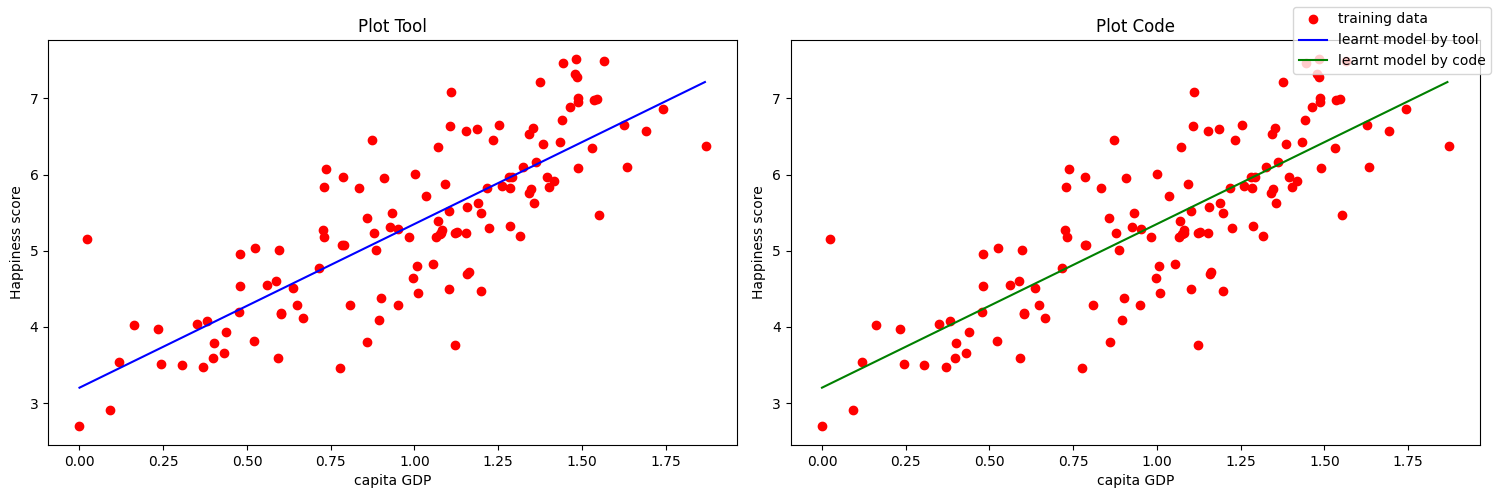

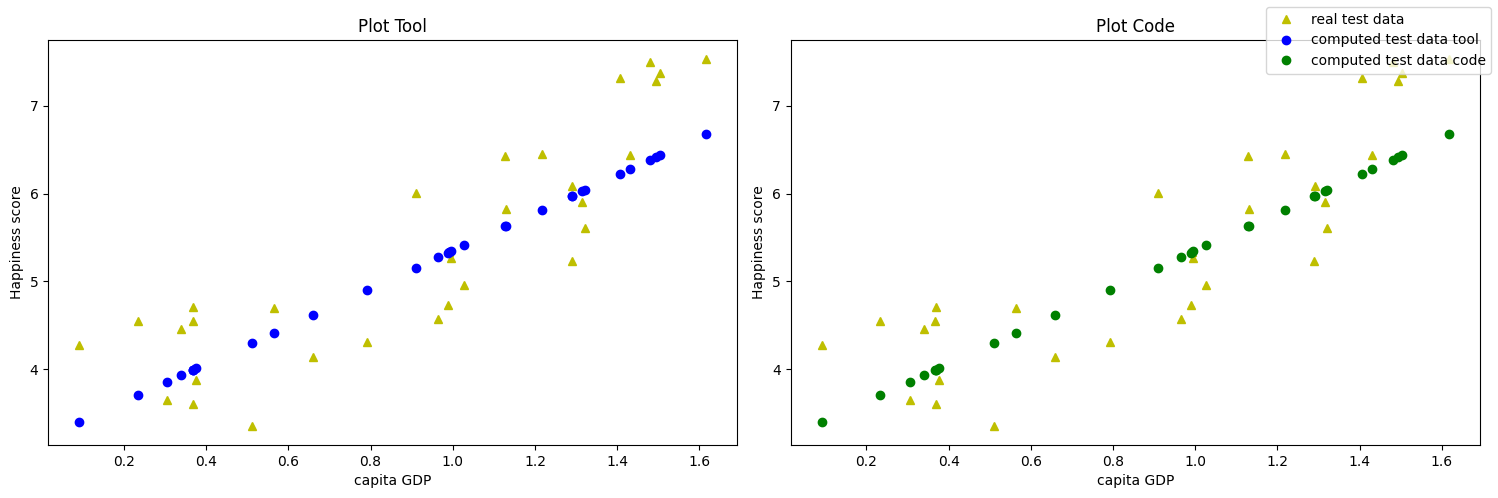

Erori outputs:
Eroare tool manuala : 0.4142120438505252
Eroare tool cu tool : 0.4142120438505258
Eroare code manuala : 0.41421204385052524
Eroare code cu tool : 0.41421204385052524


In [259]:
SolveUnivariata(filename='v2_world-happiness-report-2017.csv',
                inputVariabName='Economy..GDP.per.Capita.',
                outputVariableName='Happiness.Score',
                labelInput='capita GDP',
                labelOutput='Happiness score')

### 2. doar de caracteristica “Family”

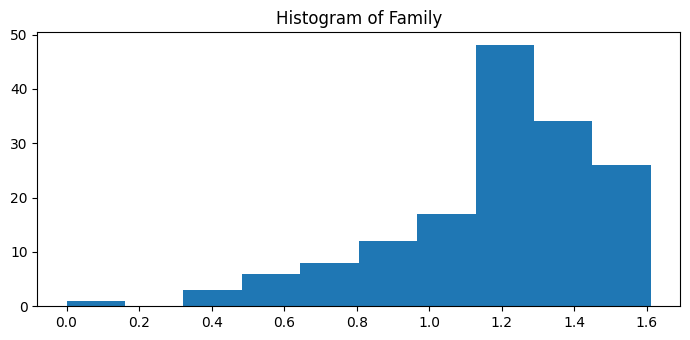

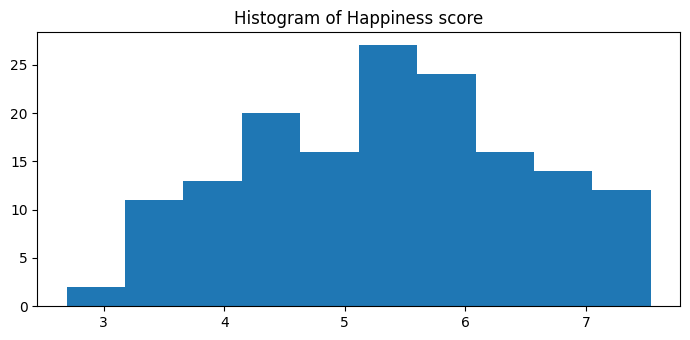

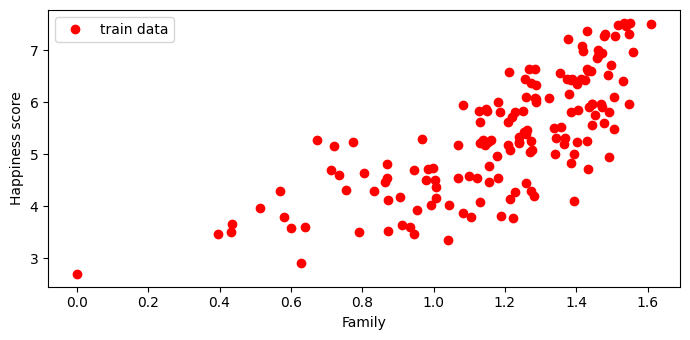

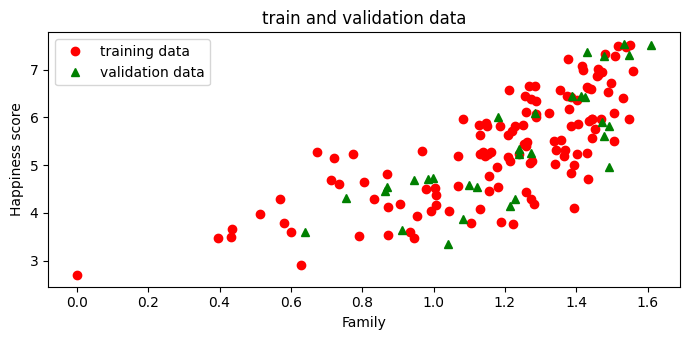

Functia calculata de tool : f(x) = 2.039013930022846 + 2.804913617557077 * x = y 
 w0 = 2.039013930022846 
 w1 = 2.804913617557077
Functia calculata de code : f(x) = 2.0390139300228274 + 2.804913617557092 * x = y 
 w0 = 2.0390139300228274 
 w1 = 2.804913617557092


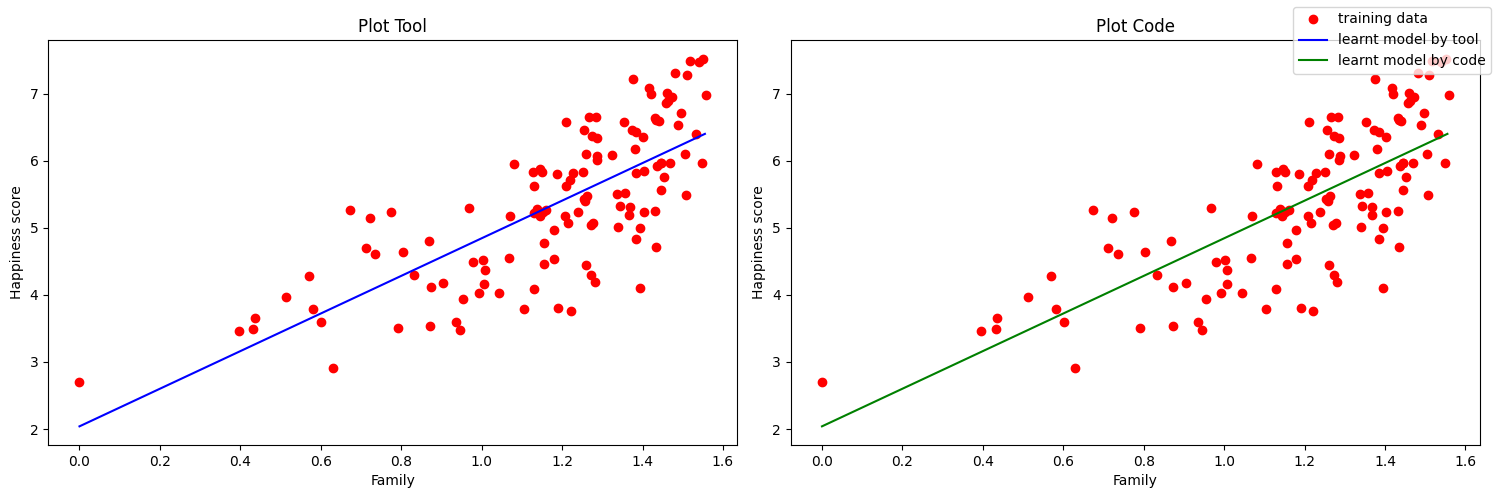

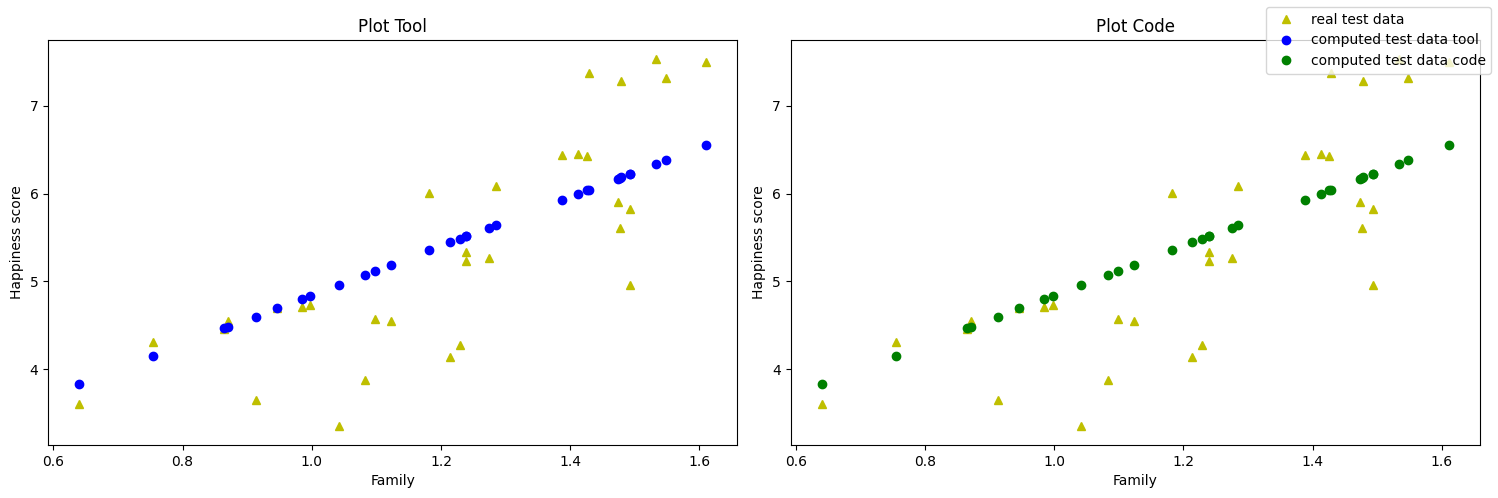

Erori outputs:
Eroare tool manuala : 0.6051231125473607
Eroare tool cu tool : 0.6051231125473586
Eroare code manuala : 0.6051231125473606
Eroare code cu tool : 0.6051231125473606


In [260]:
SolveUnivariata(filename='v2_world-happiness-report-2017.csv',
                inputVariabName='Family',
                outputVariableName='Happiness.Score',
                labelInput='Family',
                labelOutput='Happiness score')

### 3.de Produsul intern brut si de gradul de libertate.

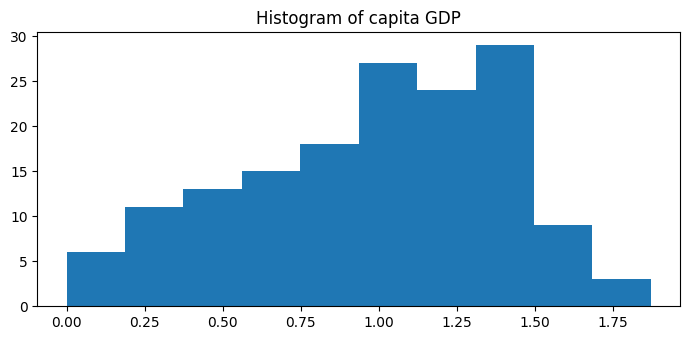

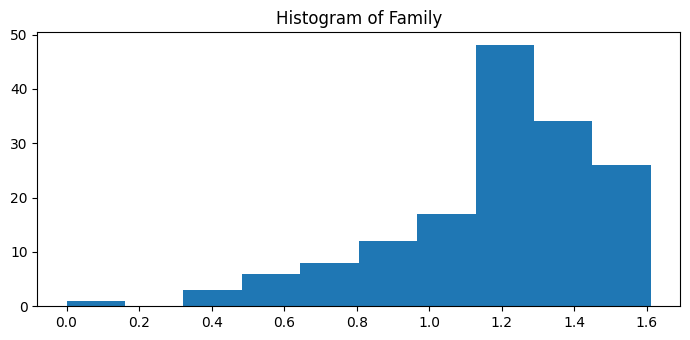

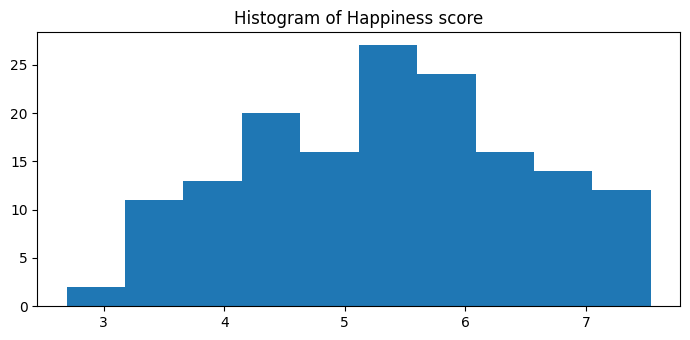

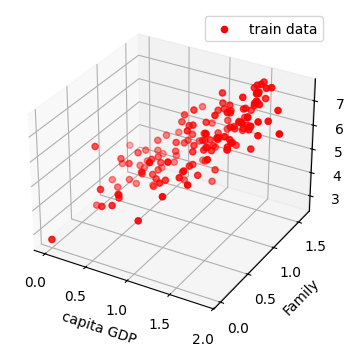

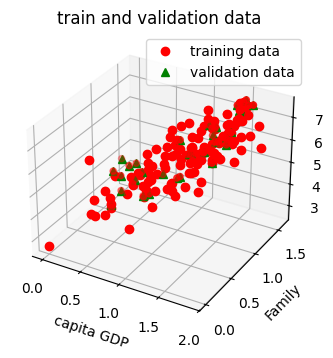

2.210885944388164
1.4646941168580385
1.4185441817784317
2.2108859443880537
1.4646941168578935
1.4185441817785405


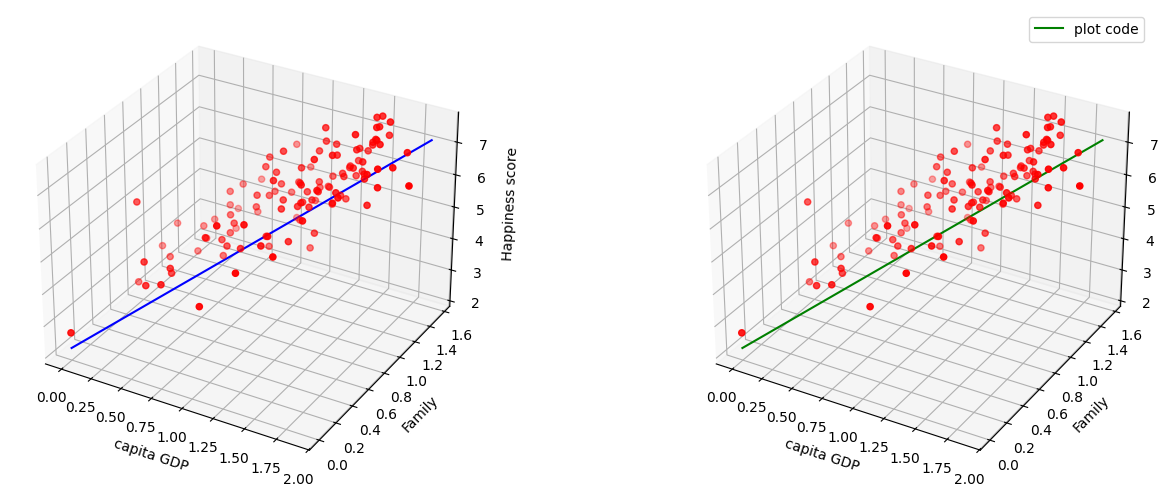

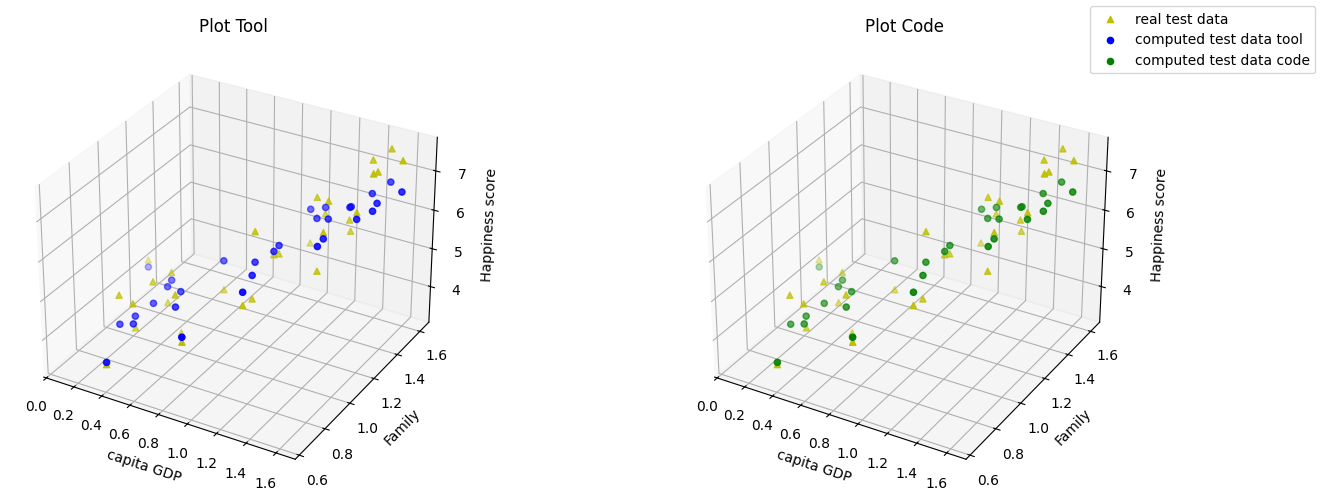

Erori outputs:
Eroare tool manuala : 0.3335443402515772
Eroare tool cu tool : 0.33354434025160207
Eroare code manuala : 0.3335443402515772
Eroare code cu tool : 0.3335443402515772


In [261]:
SolveBivariata(filename='v2_world-happiness-report-2017.csv',
               inputVariableNameFirst='Economy..GDP.per.Capita.',
               inputVariableNameSecond='Family',
               outputVariableName='Happiness.Score',
               labelInputFirst='capita GDP',
               labelInputSecond='Family',
               labelOuput='Happiness score')

## V3:

### 1. doar de Produsul intern brut 

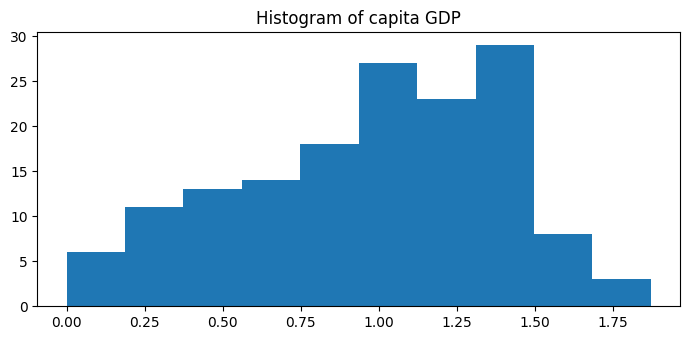

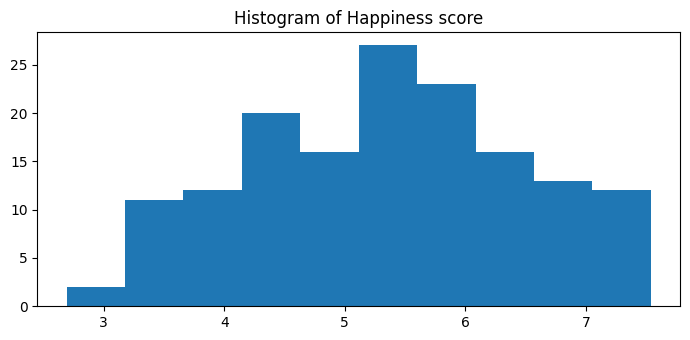

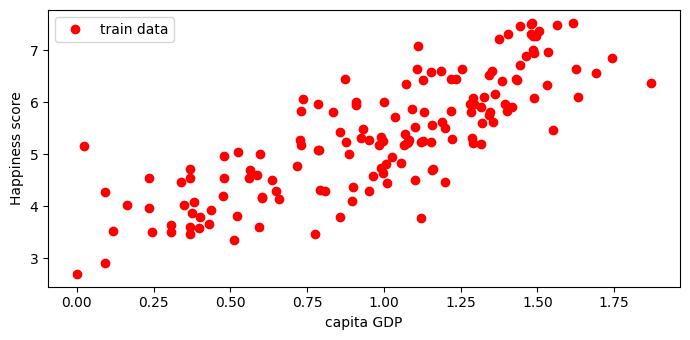

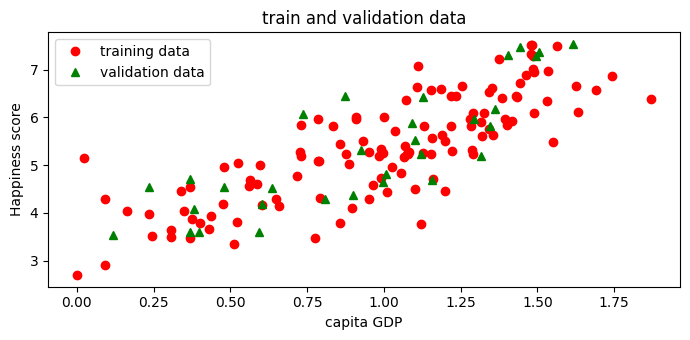

Functia calculata de tool : f(x) = 3.2590669479039853 + 2.109207536959527 * x = y 
 w0 = 3.2590669479039853 
 w1 = 2.109207536959527
Functia calculata de code : f(x) = 3.259066947903982 + 2.10920753695953 * x = y 
 w0 = 3.259066947903982 
 w1 = 2.10920753695953


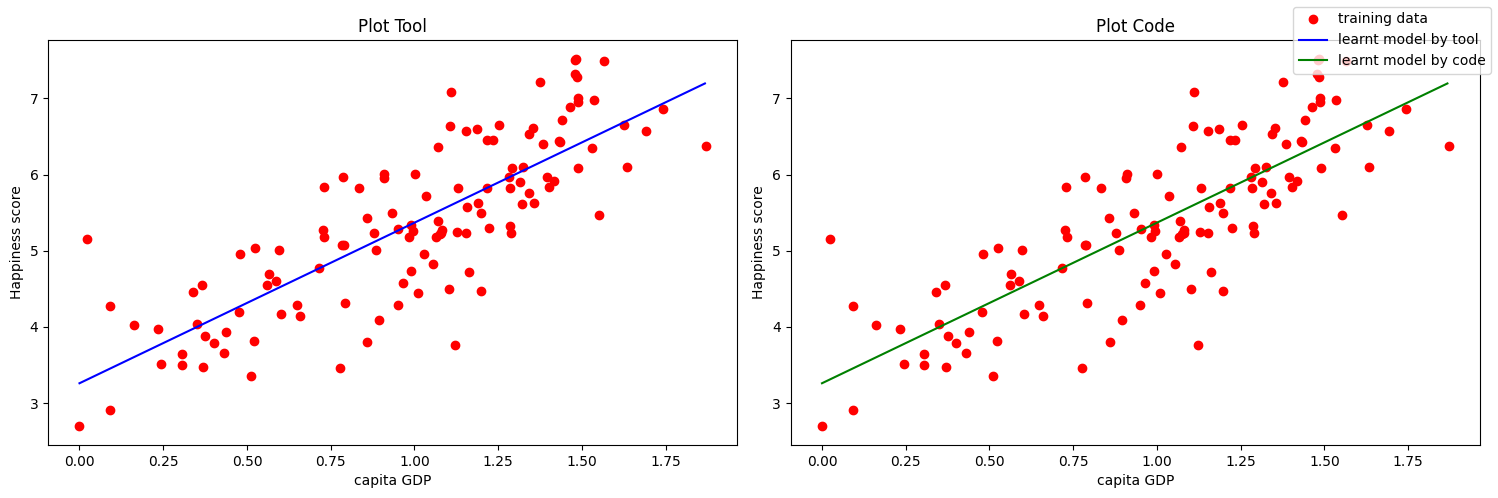

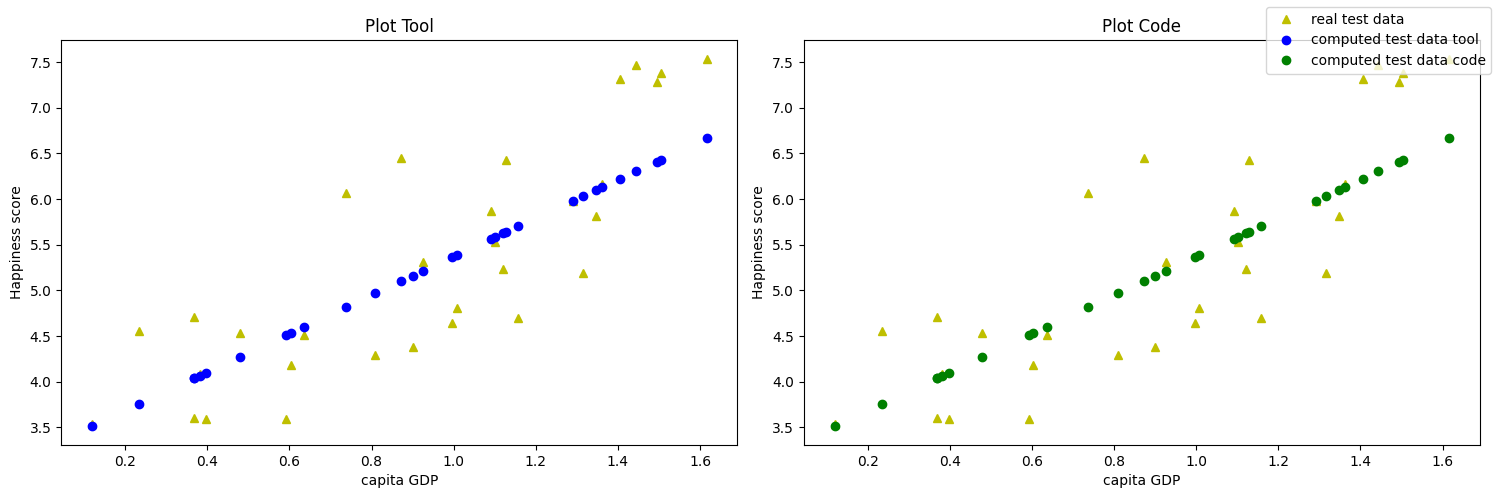

Erori outputs:
Eroare tool manuala : 0.5011920687289553
Eroare tool cu tool : 0.5011920687289552
Eroare code manuala : 0.5011920687289554
Eroare code cu tool : 0.5011920687289554


In [262]:
SolveUnivariata(filename='v3_world-happiness-report-2017.csv',
                inputVariabName='Economy..GDP.per.Capita.',
                outputVariableName='Happiness.Score',
                labelInput='capita GDP',
                labelOutput='Happiness score')

### 2. doar de caracteristica “Family”

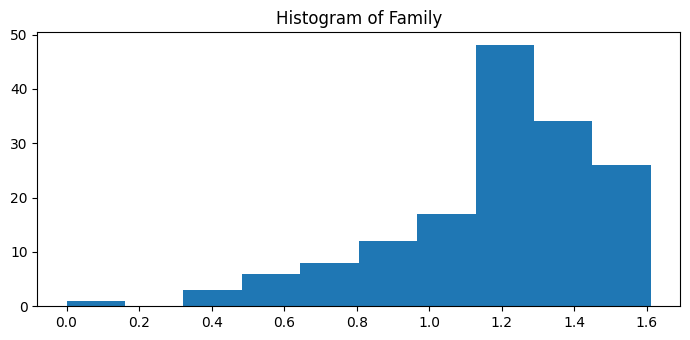

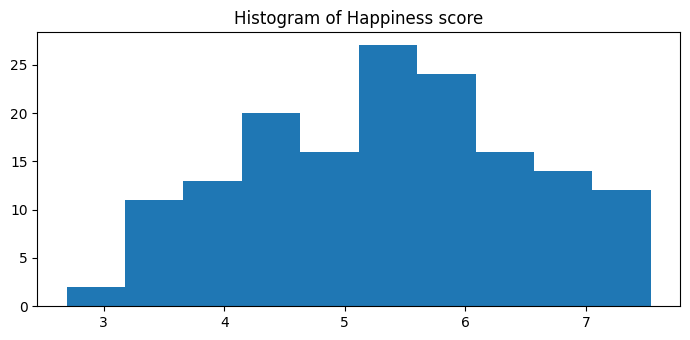

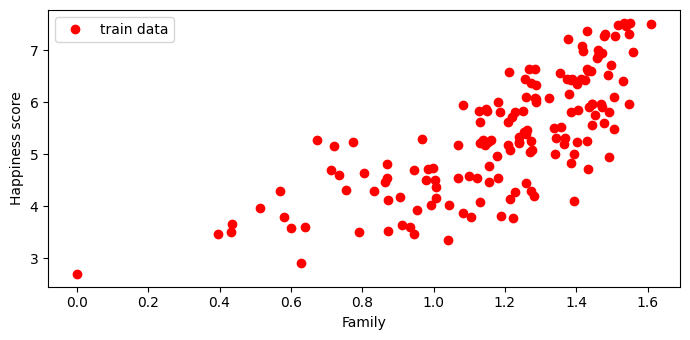

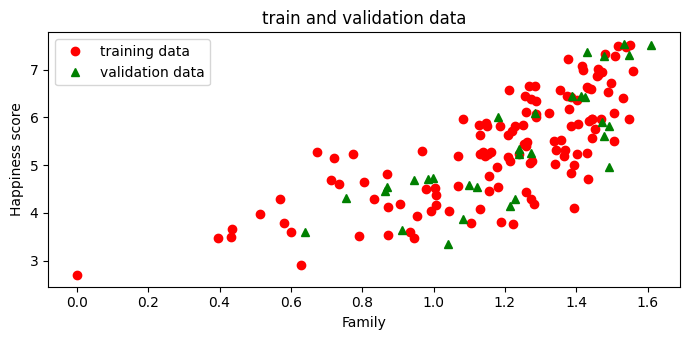

Functia calculata de tool : f(x) = 2.039013930022846 + 2.804913617557077 * x = y 
 w0 = 2.039013930022846 
 w1 = 2.804913617557077
Functia calculata de code : f(x) = 2.0390139300228274 + 2.804913617557092 * x = y 
 w0 = 2.0390139300228274 
 w1 = 2.804913617557092


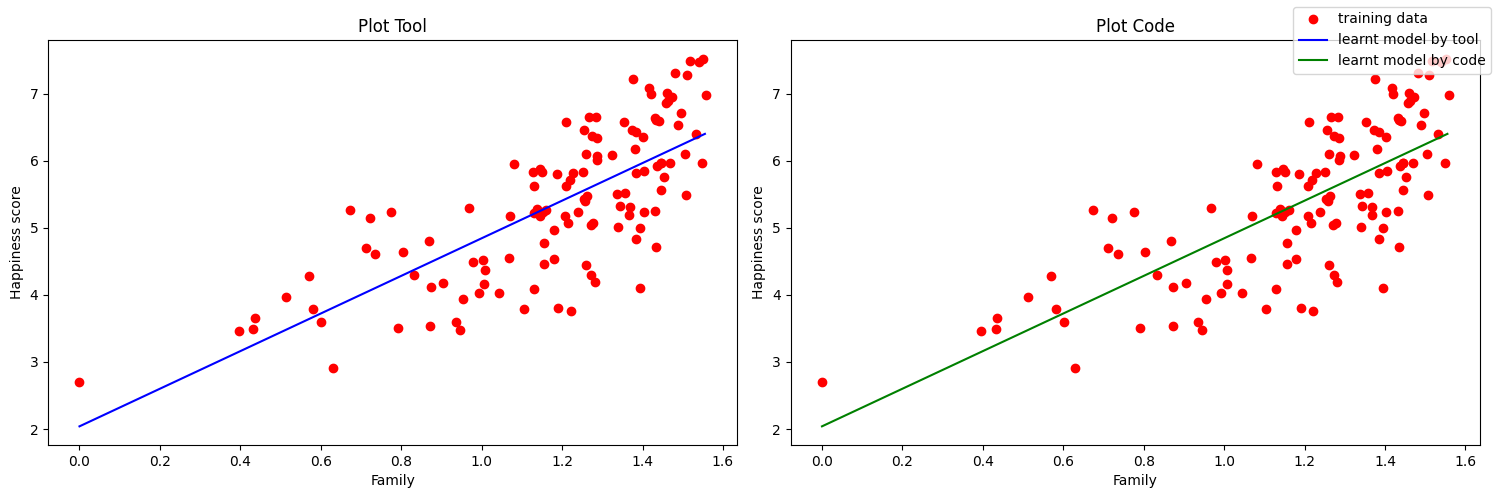

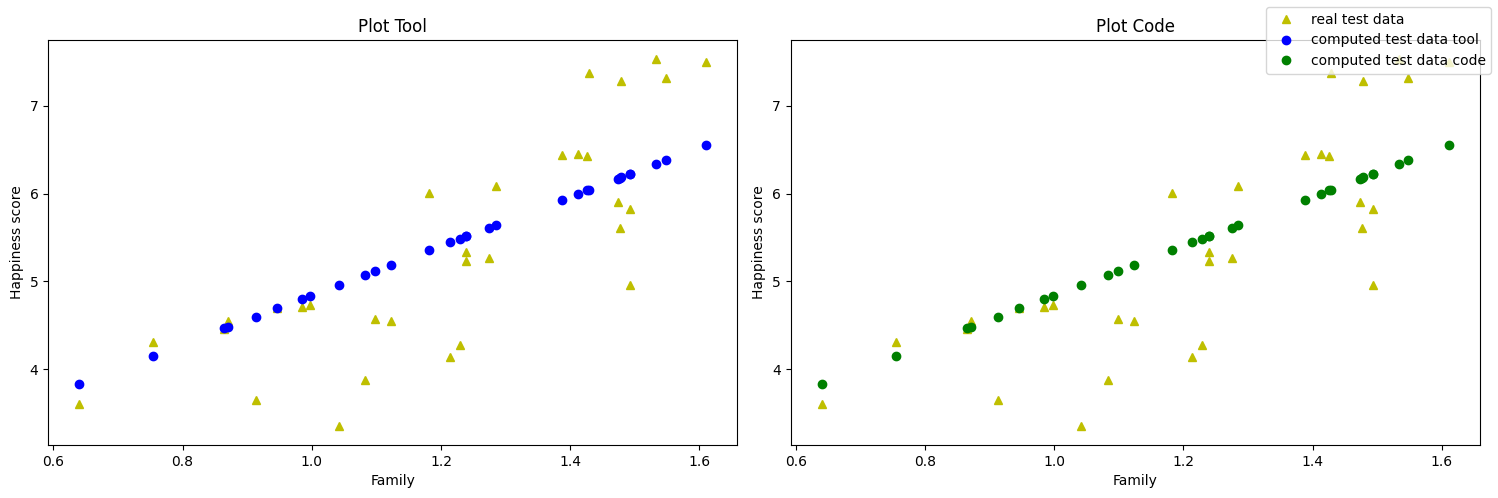

Erori outputs:
Eroare tool manuala : 0.6051231125473607
Eroare tool cu tool : 0.6051231125473586
Eroare code manuala : 0.6051231125473606
Eroare code cu tool : 0.6051231125473606


In [263]:
SolveUnivariata(filename='v3_world-happiness-report-2017.csv',
                inputVariabName='Family',
                outputVariableName='Happiness.Score',
                labelInput='Family',
                labelOutput='Happiness score')

### 3.de Produsul intern brut si de gradul de libertate.

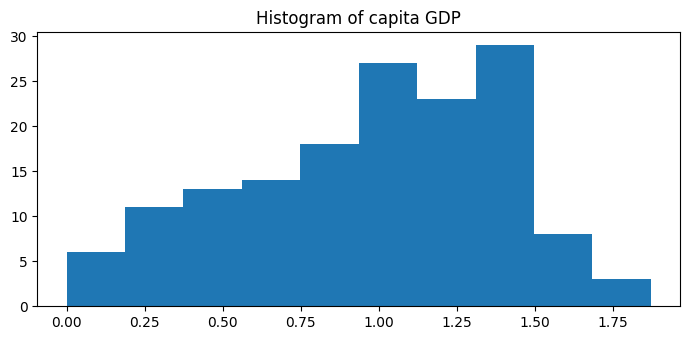

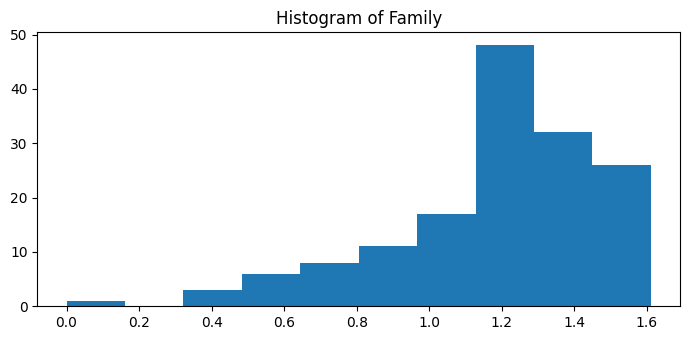

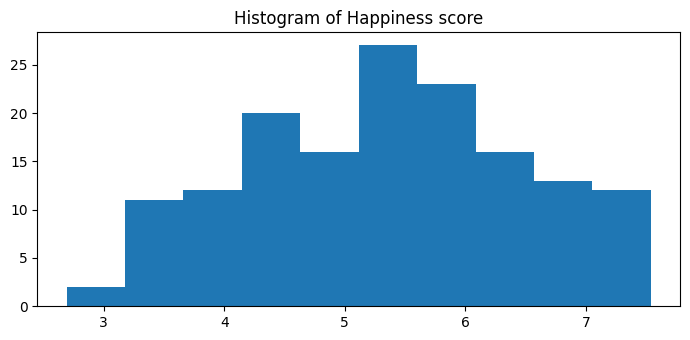

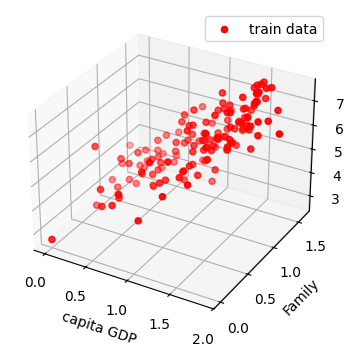

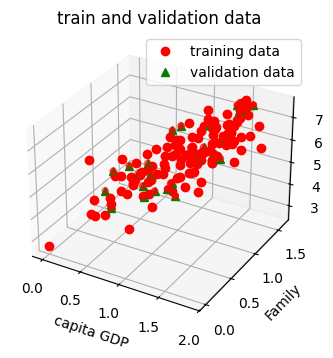

2.337928650378931
1.5325827681080189
1.245139316774131
2.3379286503788923
1.5325827681081023
1.245139316774142


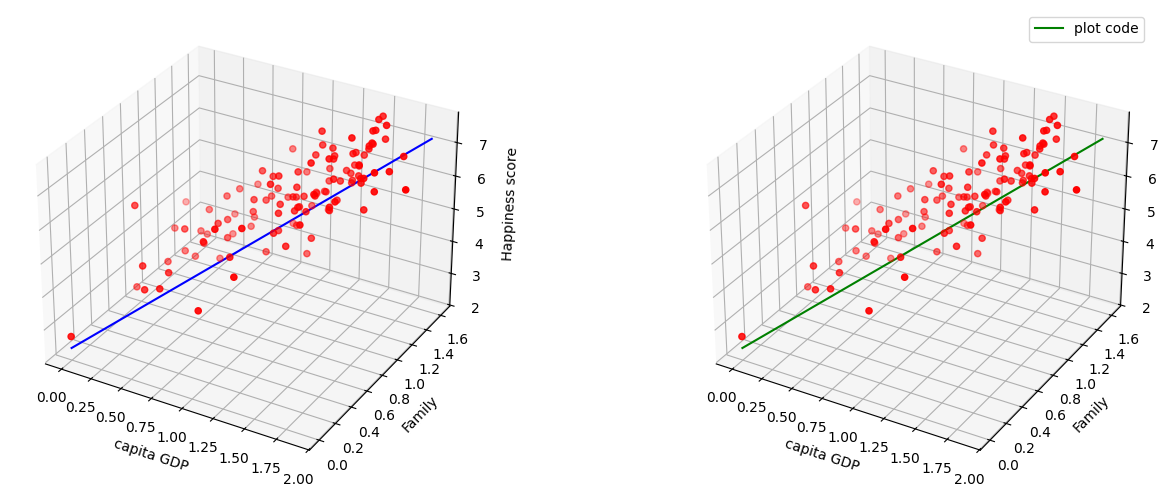

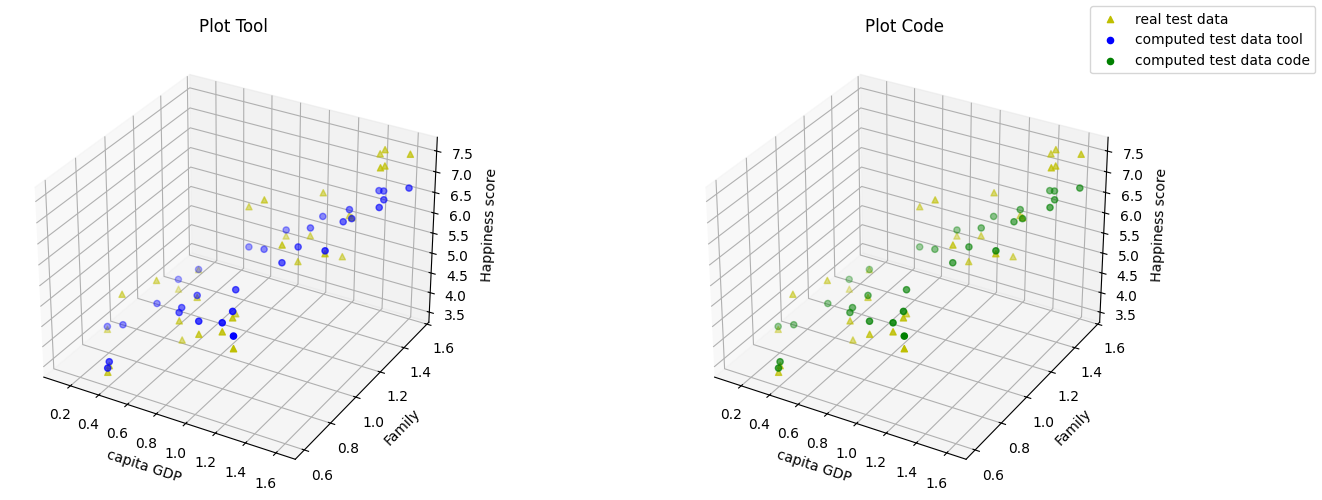

Erori outputs:
Eroare tool manuala : 0.33407871505564135
Eroare tool cu tool : 0.3340787150556168
Eroare code manuala : 0.33407871505564135
Eroare code cu tool : 0.33407871505564135


In [264]:
SolveBivariata(filename='v3_world-happiness-report-2017.csv',
               inputVariableNameFirst='Economy..GDP.per.Capita.',
               inputVariableNameSecond='Family',
               outputVariableName='Happiness.Score',
               labelInputFirst='capita GDP',
               labelInputSecond='Family',
               labelOuput='Happiness score')